# 05. Cost Function for Logistic Regression

## Why do we need a Cost Function?

After the model makes predictions,

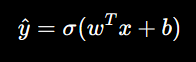

we need a way to answer:

> **"How good or bad are these predictions?"**

That is the job of the **Cost Function**.

The cost function **does not improve the model**.

It simply measures **how bad the current model is**.

---

# Why can't we use Linear Regression's Cost Function?

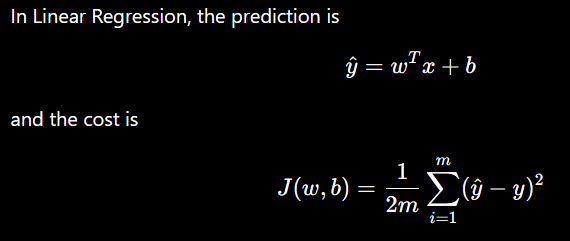

This works because the prediction is **linear** in the parameters.

The resulting cost surface is a **convex bowl**, so Gradient Descent always has a smooth path toward the global minimum.

---

## What changes in Logistic Regression?

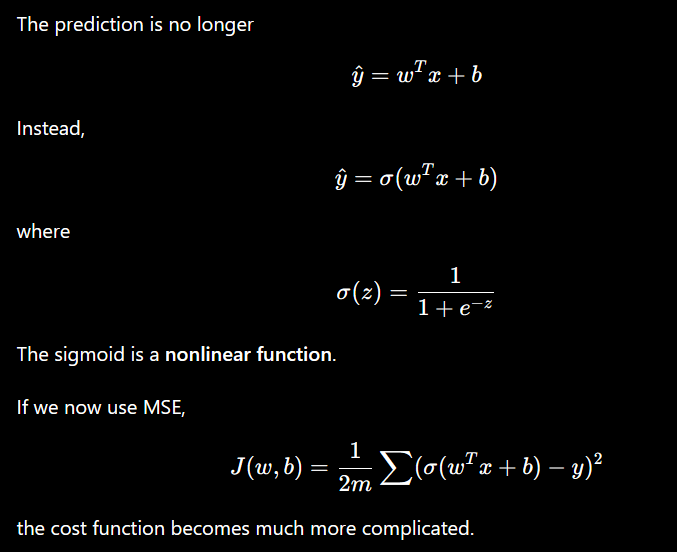

Instead of a simple convex bowl, it can have **flat regions and non-convex behavior**, making optimization with Gradient Descent much more difficult.

So the problem is **not Gradient Descent**.

The problem is the **shape of the cost function** that Gradient Descent is trying to minimize.

Therefore, for Logistic Regression we use **Cross-Entropy Loss**, which, together with the sigmoid, gives a convex optimization problem.

---

# Cross-Entropy Loss

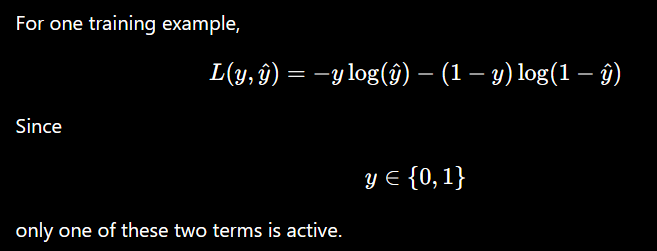

---

## Case 1 : Actual label is 1

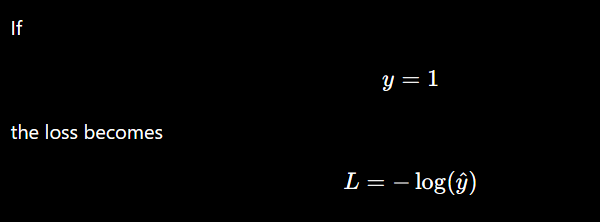

---

## Case 2 : Actual label is 0

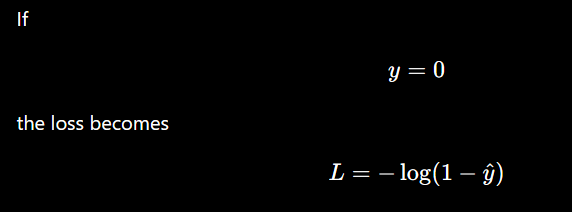

---

## Step 1: Initial Prediction

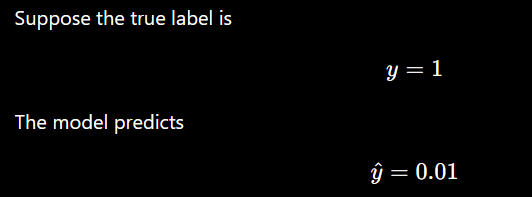

This means:

> "The model thinks there is only a **1% chance** that this belongs to class 1."

But the correct answer is actually class 1.

So the model is **very confidently wrong**.

---

## Step 2: Compute the Loss

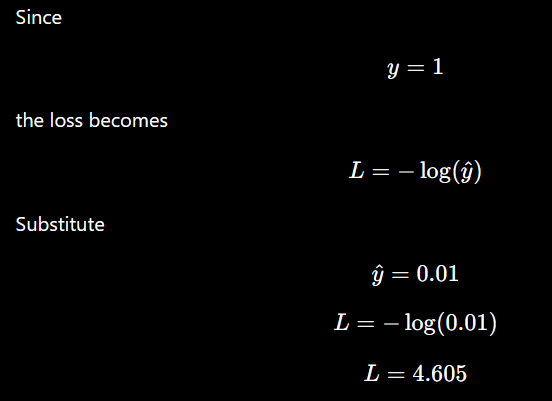

This is a **large loss**.

Notice something very important:

We are **not changing the prediction**.

We are only saying:

> "This prediction is terrible. Give it a large penalty."

---

## Step 3: Gradient Descent Uses This Loss

Now Gradient Descent asks:

> "How should I change (w) and (b) so that next time the prediction is closer to the correct answer?"

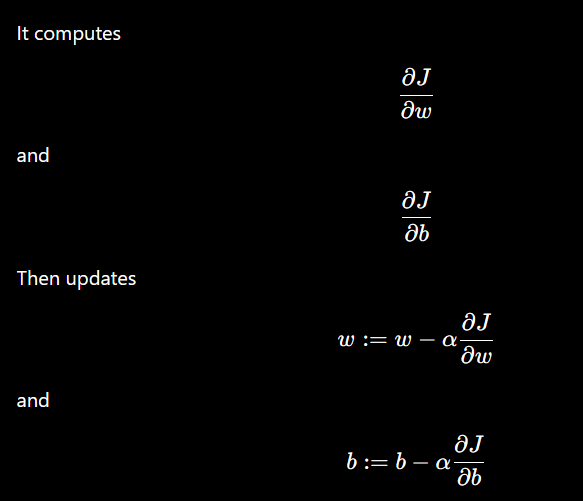

Notice:

Gradient Descent is **not using the loss directly**.

It uses the **gradient of the cost function** to decide how to update the parameters.

---

## Step 4: New Prediction

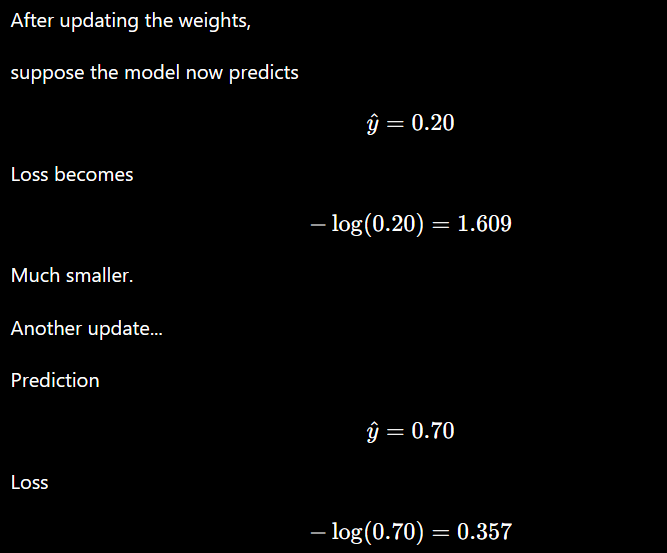

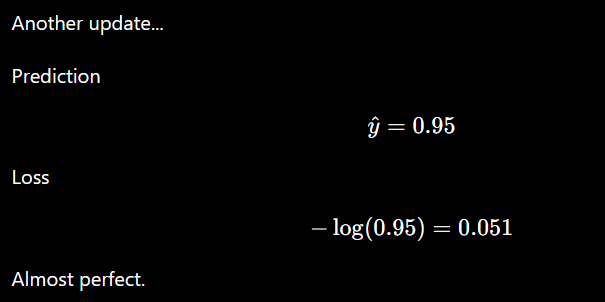

---

# Entire Learning Process

```text
Initial weights
      │
      ▼
Prediction = 0.01
      │
      ▼
Compute Loss = 4.605
      │
      ▼
Average all losses → Cost
      │
      ▼
Compute Gradient
      │
      ▼
Gradient Descent updates w,b
      │
      ▼
Prediction = 0.20
      │
      ▼
Loss = 1.609
      │
      ▼
Update weights
      │
      ▼
Prediction = 0.70
      │
      ▼
Loss = 0.357
      │
      ▼
Update weights
      │
      ▼
Prediction = 0.95
      │
      ▼
Loss = 0.051
```

Notice that **the loss never changes the prediction**.

The loss is only a **score** that tells us how bad the prediction is.

The **gradient of the cost** tells Gradient Descent **which direction to move**, and updating the weights is what changes future predictions.

---

# Why Use (-\log(\hat y))?

Look at the penalty.

| Prediction (\hat y) | Loss (when (y=1)) |
| ------------------: | ----------------: |
|                0.99 |             0.010 |
|                0.90 |             0.105 |
|                0.70 |             0.357 |
|                0.50 |             0.693 |
|                0.20 |             1.609 |
|                0.01 |             4.605 |

Exactly what we want:

* Correct and confident prediction → Tiny loss.
* Wrong and confident prediction → Huge loss.

A large loss contributes to a larger gradient, causing Gradient Descent to make a stronger correction to the parameters.

---

# One Important Clarification

Many beginners think:

> "The cost function changes 0.01 into 1."

It **does not**.

The actual learning pipeline is

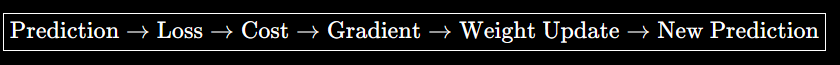

The prediction changes **only after** the weights are updated by Gradient Descent.

---
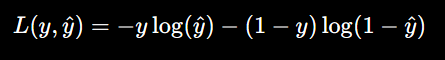

### Why not use just (\hat{y}) (or MSE) instead of the log?

Because **cross-entropy gives a much larger penalty for confident wrong predictions** and produces gradients that help the model learn faster.

### Example

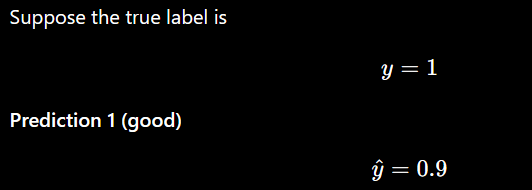

* MSE: ((1-0.9)^2 = 0.01)
* Cross-Entropy: (-\log(0.9) = 0.105)

#### Prediction 2 (very wrong)

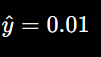

* MSE: ((1-0.01)^2 = 0.9801)
* Cross-Entropy: (-\log(0.01) = 4.605)

Notice that **cross-entropy punishes the confident wrong prediction much more heavily**.

### Summary

* **MSE**: Smaller penalty and slower learning with the sigmoid because gradients become very small.
* **Cross-Entropy**: Large penalty for confident mistakes and a simpler gradient ((\hat{y} - y)), which helps gradient descent learn efficiently.